In [10]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)
qc.qubits

[<Qubit register=(2, "q"), index=0>, <Qubit register=(2, "q"), index=1>]

In [3]:
print(type(qc.qubits[0]))

<class 'qiskit.circuit.Qubit'>


In [4]:
from qiskit.circuit import QuantumRegister, ClassicalRegister

qr1 = QuantumRegister(2, "qreg1")  # Create a QuantumRegister with 2 qubits
qr2 = QuantumRegister(1, "qreg2")  # Create a QuantumRegister with 1 qubit
cr1 = ClassicalRegister(3, "creg1")  # Create a ClassicalRegister with 3 cbits

combined_circ = QuantumCircuit(
    qr1, qr2, cr1
)  # Create a quantum circuit with 2 QuantumRegisters and 1 ClassicalRegister
combined_circ.qubits

[<Qubit register=(2, "qreg1"), index=0>,
 <Qubit register=(2, "qreg1"), index=1>,
 <Qubit register=(1, "qreg2"), index=0>]

You can find a qubit's index and register by using the circuit's find_bit method and its attributes.

In [5]:
desired_qubit = qr2[0]  # Qubit 0 of register 'qreg2'

print("Index:", combined_circ.find_bit(desired_qubit).index)
print("Register:", combined_circ.find_bit(desired_qubit).registers)

Index: 2
Register: [(QuantumRegister(1, 'qreg2'), 0)]


Adding an instruction to the circuit appends the instruction to the circuit's **data** attribute. The following cell output shows data is a list of CircuitInstruction objects, each of which has an operation attribute, and a qubits attribute.

In [11]:
qc.x(0)  # Add X-gate to qubit 0
qc.h(1)
qc.data

[CircuitInstruction(operation=Instruction(name='x', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=0>,), clbits=()), CircuitInstruction(operation=Instruction(name='h', num_qubits=1, num_clbits=0, params=[]), qubits=(<Qubit register=(2, "q"), index=1>,), clbits=())]

In [29]:
print(type(qc.data[0].qubits))
print(qc.data[0].qubits[0])
print(type(qc.data[0].qubits[0]))

# FOR EXTRACTING THE INDEX!!!
print(qc.data[0].qubits[0]._index)

print(qc.data[0].operation)

<class 'tuple'>
<Qubit register=(2, "q"), index=0>
<class 'qiskit.circuit.Qubit'>
0
Instruction(name='x', num_qubits=1, num_clbits=0, params=[])


Circuit **Instruction** objects can contain "definition" circuits that describe the instruction in terms of more fundamental instructions. For example, the X-gate is defined as a specific case of the U3-gate, a more general single-qubit gate.

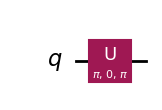

In [28]:
# Draw definition circuit of 0th instruction in `qc`
qc.data[0].operation.definition.draw("mpl")

## Build Circuits

Methods such as QuantumCircuit.h and QuantumCircuit.cx add specific instructions to circuits. To add instructions to a circuit more generally, use the append method. This takes an instruction and a list of qubits to apply the instruction to. See the Circuit Library API documentation for a list of supported instructions.

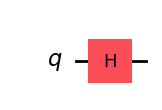

In [30]:
from qiskit.circuit.library import HGate

qc = QuantumCircuit(1)
qc.append(
    HGate(),  # New HGate instruction
    [0],  # Apply to qubit 0
)
qc.draw("mpl")

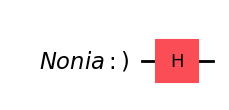

In [31]:
from qiskit.circuit.library import HGate
from qiskit import QuantumRegister
qreg = QuantumRegister(1, 'Nonia:)')
qc = QuantumCircuit(qreg)
qc.append(
    HGate(),  # New HGate instruction
    [0],  # Apply to qubit 0
)
qc.draw("mpl")

To combine two circuits, use the compose method. This accepts another QuantumCircuit and an optional list of qubit mappings.



The compose method returns a new circuit and does not mutate either circuit it acts on. To mutate the circuit on which you're calling the compose method, use the argument inplace=True.

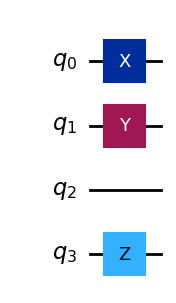

In [35]:
qc_a = QuantumCircuit(4)
qc_a.x(0)

qc_b = QuantumCircuit(2, name="qc_b")
qc_b.y(0)
qc_b.z(1)

# compose qubits (0, 1) of qc_a to qubits (1, 3) of qc_b respectively
combined = qc_a.compose(qc_b, qubits=[1, 3])
combined.draw("mpl")

You might also want to compile circuits into instructions to keep your circuits organized. You can convert a circuit to an instruction by using the to_instruction method, then append this to another circuit as you would any other instruction. The circuit drawn in the following cell is functionally equivalent to the circuit drawn in the previous cell.

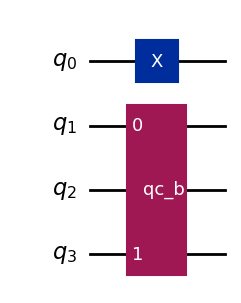

In [36]:
inst = qc_b.to_instruction()
qc_a.append(inst, [1, 3])
qc_a.draw("mpl")

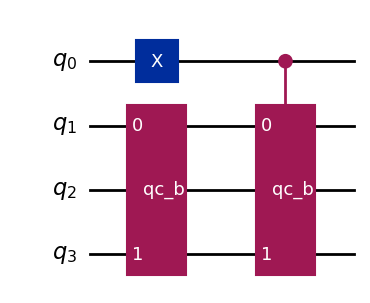

In [37]:
gate = qc_b.to_gate().control()
qc_a.append(gate, [0, 1, 3])
qc_a.draw("mpl")

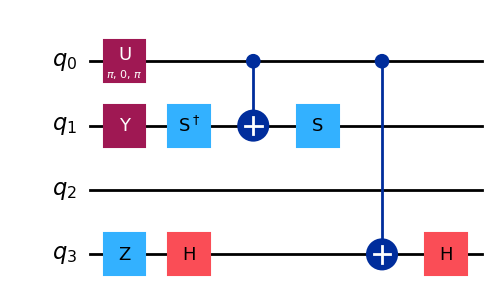

In [38]:
qc_a.decompose().draw("mpl")

## Measure qubits